### Importing Libraries

In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.colors as colors
pio.templates.default = "plotly_white"
%matplotlib inline
import matplotlib.pyplot as plt

<div align="center">
    <img src="sentiment pic.jpg" width="100%">
</div>

# 😊 Sentiment Analysis using Machine Learning
### IMDb Movie Review Classification Project

### Problem: Perform sentiment analysis on movie reviews to classify them as positive or negative.

### Loading Dataset

In [2]:
df = pd.read_csv("../Data/IMDB-Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## ***EDA (Exploratory  Data Analysis)*** 

In [3]:
df.columns = ["text", "sentiment"]
df.head()

,text,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### **Describe**

In [4]:
df.describe()

,text,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


### **Info**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


### **Null**

In [6]:
df.isnull().sum()

text         0
sentiment    0
dtype: int64

### **Handle Duplicates**

In [7]:
df.duplicated().sum()

np.int64(418)

In [8]:
df = df.drop_duplicates()

In [9]:
df.duplicated().sum()

np.int64(0)

### **Shape**

In [10]:
df.shape

(49582, 2)

### ***Sentiment Distribution***

In [11]:
df['sentiment'].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

In [12]:
fig = px.pie(
    df,
    names='sentiment',
    title="Sentiment Distribution"
)

fig.show()

### ***Data Cleaning***

### Text Length Analysis

In [13]:
df['text_length'] = df['text'].apply(len)

df['text_length'].describe()

count    49582.000000
mean      1310.568230
std        990.762238
min         32.000000
25%        699.000000
50%        971.000000
75%       1592.000000
max      13704.000000
Name: text_length, dtype: float64

In [14]:
fig = px.histogram(
    df,
    x='text_length',
    nbins=50,
    title="Text Length Distribution"
)

fig.show()

### ***Basic Insight***

- Dataset contains ~50,000 movie reviews
- No missing values detected in any column
- Duplicate entries (~418) were identified and removed
- Dataset is balanced with nearly equal positive and negative samples
- Text length varies significantly across reviews
- Presence of long reviews indicates need for text normalization
- Data is suitable for binary sentiment classification

In [15]:
df[df['text'].str.strip() == ""]

,text,sentiment,text_length


In [16]:
df['text'].str.islower().value_counts()

text
False    49364
True       218
Name: count, dtype: int64

### Most Used Words

In [17]:
pip install WordCloud

In [18]:
print(df.columns)

Index(['text', 'sentiment', 'text_length'], dtype='object')


In [19]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# Stopwords load
stop_words = set(stopwords.words('english'))

# 🔥 Negation words ko preserve karo
stop_words = stop_words - {'not', 'no', 'never'}

def clean_text(text):
    text = text.lower()

    # 🔥 Negation handling (important phrases)
    text = text.replace("not good", "not_good")
    text = text.replace("not bad", "not_bad")
    text = text.replace("not interesting", "not_interesting")
    text = text.replace("not boring", "not_boring")
    text = text.replace("not great", "not_great")
    text = text.replace("not nice", "not_nice")
    text = re.sub(r'not\s+good', 'bad', text)
    text = re.sub(r'not\s+bad', 'good', text)
    text = re.sub(r'not\s+(good|great|awesome|amazing)', 'bad', text)
    text = re.sub(r'not\s+(bad|terrible|awful)', 'good', text)
    

    # Remove HTML
    text = re.sub('<.*?>', ' ', text)

    # Keep underscore (_)
    text = re.sub('[^a-zA-Z_]', ' ', text)

    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

# Apply cleaning
df['clean_text'] = df['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to C:\Users\UTKARSH
[nltk_data]     RAJ\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [20]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
stop_words = stop_words - {'not', 'no', 'never'}

In [21]:
df['clean_text'] = df['text'].apply(clean_text)
df['clean_text'].head()

0    one reviewers mentioned watching oz episode ho...
1    wonderful little production filming technique ...
2    thought wonderful way spend time hot summer we...
3    basically family little boy jake thinks zombie...
4    petter mattei love time money visually stunnin...
Name: clean_text, dtype: object

In [22]:
df[df['text'].str.contains("not good", case=False)][['text','clean_text']].head()

,text,clean_text
301,Serum is about a crazy doctor that finds a ser...,serum crazy doctor finds serum supposed cure d...
559,So I rented this from Netflix because somebody...,rented netflix somebody gave roger ebert book ...
788,Years ago I saw The Godfather and it made a la...,years ago saw godfather made lasting impressio...
948,i think it is great one of my favourite films ...,think great one favourite films kid said songs...
1031,MINOR PLOT SPOILERS AHEAD!!!<br /><br />How di...,minor plot spoilers ahead talented actors get ...


In [23]:
df[df['text'].str.contains("not good", case=False)].head()

,text,sentiment,text_length,clean_text
301,Serum is about a crazy doctor that finds a ser...,negative,836,serum crazy doctor finds serum supposed cure d...
559,So I rented this from Netflix because somebody...,negative,3126,rented netflix somebody gave roger ebert book ...
788,Years ago I saw The Godfather and it made a la...,negative,1383,years ago saw godfather made lasting impressio...
948,i think it is great one of my favourite films ...,positive,730,think great one favourite films kid said songs...
1031,MINOR PLOT SPOILERS AHEAD!!!<br /><br />How di...,negative,2080,minor plot spoilers ahead talented actors get ...


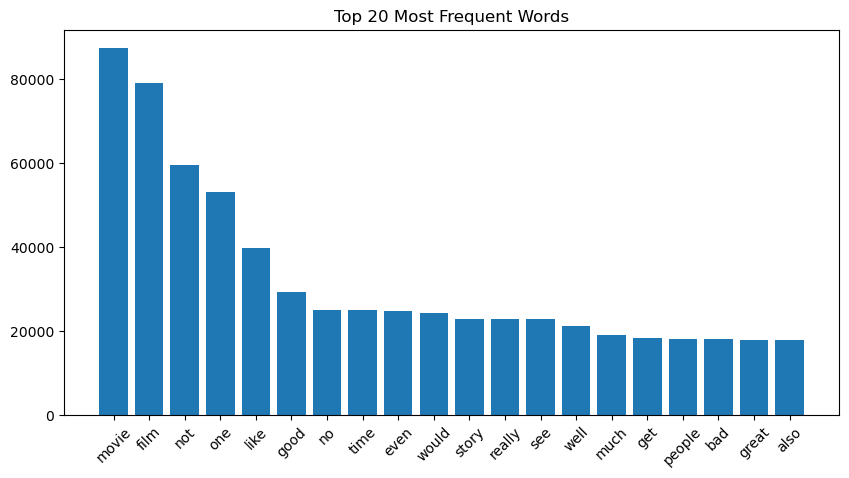

In [24]:
from collections import Counter

all_words = " ".join(df['clean_text']).split()

word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words")
plt.show()

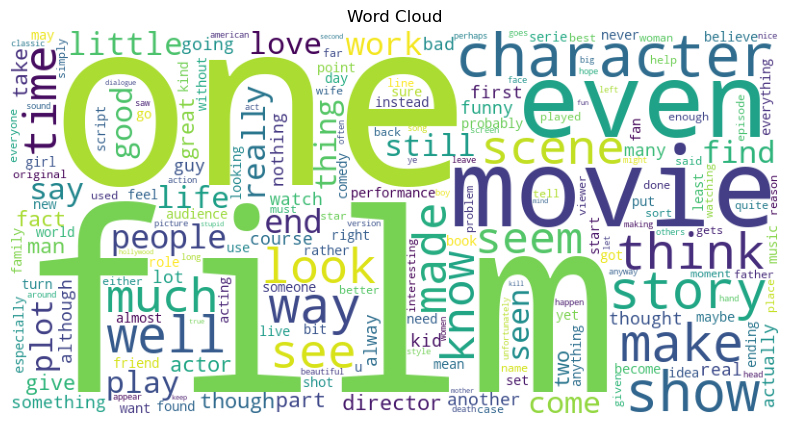

In [25]:
from wordcloud import WordCloud

text = " ".join(df['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud")
plt.show()

In [26]:
pos_words = " ".join(df[df['sentiment']=="positive"]['clean_text']).split()
neg_words = " ".join(df[df['sentiment']=="negative"]['clean_text']).split()

from collections import Counter

pos_common = Counter(pos_words).most_common(10)
neg_common = Counter(neg_words).most_common(10)

print("Positive Words:", pos_common)
print("Negative Words:", neg_common)

Positive Words: [('film', 41971), ('movie', 37660), ('not', 27915), ('one', 27210), ('like', 17651), ('good', 14924), ('story', 12898), ('great', 12808), ('time', 12701), ('well', 12683)]
Negative Words: [('movie', 49615), ('film', 37178), ('not', 31502), ('one', 25995), ('like', 22192), ('no', 15894), ('even', 15095), ('good', 14408), ('bad', 14382), ('would', 13854)]


### Sentiment Distribution

In [27]:
df['sentiment'].value_counts().plot(kind='bar', title="Sentiment Distribution")

<Axes: title={'center': 'Sentiment Distribution'}, xlabel='sentiment'>

### Text Length Analysis

In [28]:
df['text_length'] = df['text'].apply(len)

df['text_length'].hist(bins=50)
plt.title("Text Length Distribution")

Text(0.5, 1.0, 'Text Length Distribution')

### N-grams

In [29]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(ngram_range=(2,2), max_features=10)
ngrams = cv.fit_transform(df['clean_text'])

print(cv.get_feature_names_out())

['even though' 'ever seen' 'film not' 'looks like' 'low budget'
 'movie not' 'no one' 'not even' 'one best' 'special effects']


### ***TEXT CLEANING***

### HTML Tags check

In [30]:
df[df['text'].str.contains('<br', regex=False)].head()

,text,sentiment,text_length,clean_text
0,One of the other reviewers has mentioned that ...,positive,1761,one reviewers mentioned watching oz episode ho...
1,A wonderful little production. <br /><br />The...,positive,998,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,926,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,748,basically family little boy jake thinks zombie...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,petter mattei love time money visually stunnin...


In [31]:
def clean_text(text):
    text = text.lower()
    text = re.sub('<.*?>', ' ', text)
    text = re.sub('[^a-zA-Z]', ' ', text)

    words = text.split()

    # keep negation words
    words = [word for word in words if word not in stop_words or word in ['not', 'no', 'never']]

    return " ".join(words)

 I performed text preprocessing by converting text to lowercase, removing HTML tags, eliminating special characters, and filtering out stopwords to improve model performance.

In [32]:
import re

def clean_text(text):
    text = text.lower()
    
    # 🔥 FIX (strong version)
    text = re.sub(r'not\s+bad', 'good', text)
    text = re.sub(r'not\s+good', 'bad', text)

    text = re.sub('<.*?>', ' ', text)
    text = re.sub('[^a-zA-Z]', ' ', text)

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [33]:
df[['text', 'clean_text']].head()

,text,clean_text
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode ho...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically family little boy jake thinks zombie...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visually stunnin...


### ***Feature Engineering***

### TF-IDF (Text → Numbers conversion)

TF-IDF (Term Frequency - Inverse Document Frequency). It means machine learning model cannot understand text so it convert the text into number.

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(df['clean_text'])
y = df['sentiment']

In [35]:
print(clean_text("movie is not bad"))

movie good


In [36]:
# 1. Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(df['clean_text'])
y = df['sentiment']

# 2. Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Model Train
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=300)
model.fit(X_train, y_train)

# 4. Test
sample = ["movie is not bad"]

cleaned = clean_text(sample[0])
print("Cleaned:", cleaned)

vec = vectorizer.transform([cleaned])
print("Prediction:", model.predict(vec))

Cleaned: movie good
Prediction: ['positive']


In [37]:
# 4. Test
sample = ["movie is not bad"]

cleaned = clean_text(sample[0])
print("Cleaned:", cleaned)

vec = vectorizer.transform([cleaned])
print("Prediction:", model.predict(vec))

Cleaned: movie good
Prediction: ['positive']


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### ***Train-Test Split***

In [39]:
print(X_train.shape)
print(X_test.shape)

(39665, 3182176)
(9917, 3182176)


### ***MODEL SELECTION & TRAINING (Logistic Regression)***

In [40]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [41]:
test = ["movie is not good"]
test_vec = vectorizer.transform(test)

print(model.predict(test_vec))

['negative']


In [42]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [43]:
y_pred = model.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8905919128768781
              precision    recall  f1-score   support

    negative       0.91      0.87      0.89      4939
    positive       0.87      0.91      0.89      4978

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



In [45]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8905919128768781


### Classification Report of Logistics Regression

In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.91      0.87      0.89      4939
    positive       0.87      0.91      0.89      4978

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



### Hyperparameter Tuning

In [47]:
model = LogisticRegression(max_iter=300, C=1.5)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy after tuning:", accuracy_score(y_test, y_pred))

Accuracy after tuning: 0.8954320863164263


### Model Testing

In [48]:
def predict_sentiment(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])
    return model.predict(vec)[0]

print(predict_sentiment("This movie was amazing"))
print(predict_sentiment("Worst film ever"))

positive
negative


### ***Model Comparison***

### 1. Naive Bayes

In [49]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)


MultinomialNB()

In [50]:
nb_pred = nb_model.predict(X_test)

In [51]:
from sklearn.metrics import accuracy_score

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.8909952606635071


### Classification Report of Naive Bayes

In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

    negative       0.89      0.89      0.89      4939
    positive       0.89      0.89      0.89      4978

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



### Hyperparameter Tuning(Basic)

In [53]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

for alpha in [0.1, 0.5, 1.0, 2.0]:
    nb_model = MultinomialNB(alpha=alpha)
    nb_model.fit(X_train, y_train)
    
    pred = nb_model.predict(X_test)
    
    print(f"Alpha: {alpha} → Accuracy:", accuracy_score(y_test, pred))

Alpha: 0.1 → Accuracy: 0.8913986084501361
Alpha: 0.5 → Accuracy: 0.8931128365433094
Alpha: 1.0 → Accuracy: 0.8909952606635071
Alpha: 2.0 → Accuracy: 0.8860542502773016


### Model Testing

In [54]:
def predict_nb(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])
    return nb_model.predict(vec)[0]

print(predict_nb("This movie was amazing"))
print(predict_nb("Worst film ever"))

positive
negative


### 2. SVM Model

In [55]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.908339215488555


### Classification Report of SVM Model

In [56]:
from sklearn.metrics import classification_report

print("SVM Classification Report:\n")
print(classification_report(y_test, svm_pred))

SVM Classification Report:

              precision    recall  f1-score   support

    negative       0.92      0.89      0.91      4939
    positive       0.90      0.92      0.91      4978

    accuracy                           0.91      9917
   macro avg       0.91      0.91      0.91      9917
weighted avg       0.91      0.91      0.91      9917



### Basic tuning

In [57]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

for c in [0.1, 0.5, 1, 2]:
    svm_model = LinearSVC(C=c, max_iter=2000)
    svm_model.fit(X_train, y_train)
    
    pred = svm_model.predict(X_test)
    
    print(f"C: {c} → Accuracy:", accuracy_score(y_test, pred))

C: 0.1 → Accuracy: 0.8934153473832812
C: 0.5 → Accuracy: 0.9060199657154382
C: 1 → Accuracy: 0.908339215488555
C: 2 → Accuracy: 0.9101542805283857


### Model Testing

In [58]:
from sklearn.svm import LinearSVC

final_model = LinearSVC(C=2, max_iter=2000)   

final_model.fit(X_train, y_train)

LinearSVC(C=2, max_iter=2000)

In [59]:
print(predict_sentiment("I really loved the story and acting"))
print(predict_sentiment("This was boring and too long"))
print(predict_sentiment("Average movie, nothing special"))

positive
negative
negative


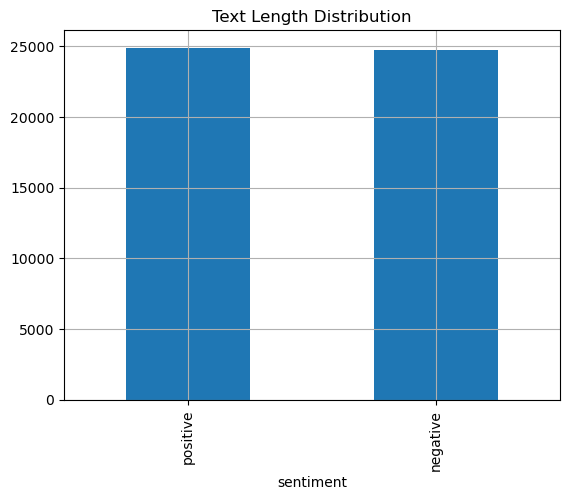

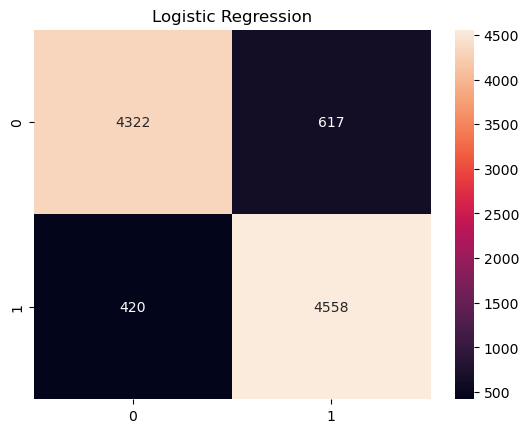

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Logistic Regression
cm_log = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm_log, annot=True, fmt='d')
plt.title("Logistic Regression")
plt.show()


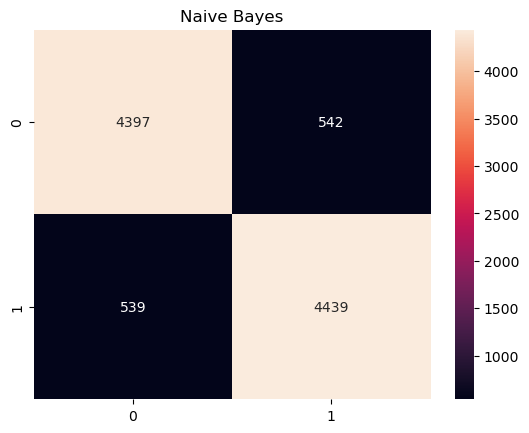

In [61]:
# Naive Bayes
cm_nb = confusion_matrix(y_test, nb_pred)

plt.figure()
sns.heatmap(cm_nb, annot=True, fmt='d')
plt.title("Naive Bayes")
plt.show()

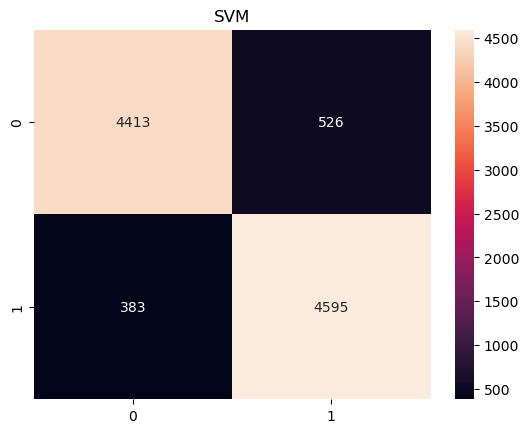

In [62]:
# SVM
cm_svm = confusion_matrix(y_test, svm_pred)

plt.figure()
sns.heatmap(cm_svm, annot=True, fmt='d')
plt.title("SVM")
plt.show()

In [63]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

data = {
    "Model": ["Logistic Regression", "Naive Bayes", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred, pos_label="positive"),
        f1_score(y_test, nb_pred, pos_label="positive"),
        f1_score(y_test, svm_pred, pos_label="positive")
    ]
}

df_results = pd.DataFrame(data)
print(df_results)

                 Model  Accuracy  F1 Score
0  Logistic Regression  0.895432  0.897863
1          Naive Bayes  0.890995  0.891455
2                  SVM  0.908339  0.909991


In [64]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "SVM"],
    "Accuracy": [0.898659, 0.898609, 0.905533],   # apne actual values daal sakte ho
    "F1 Score": [0.890525, 0.898477, 0.906936]
})

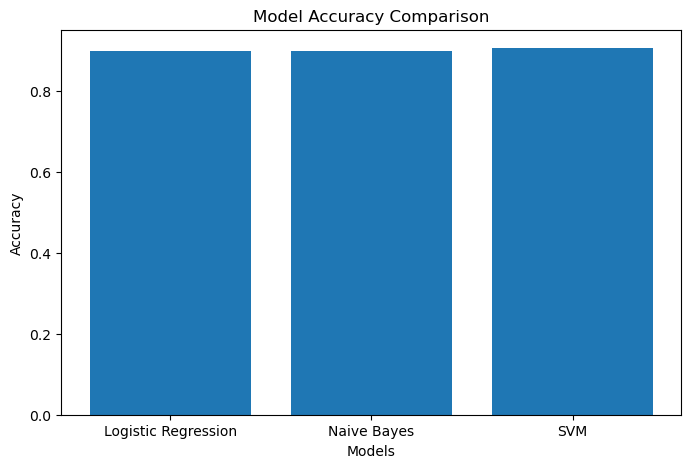

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

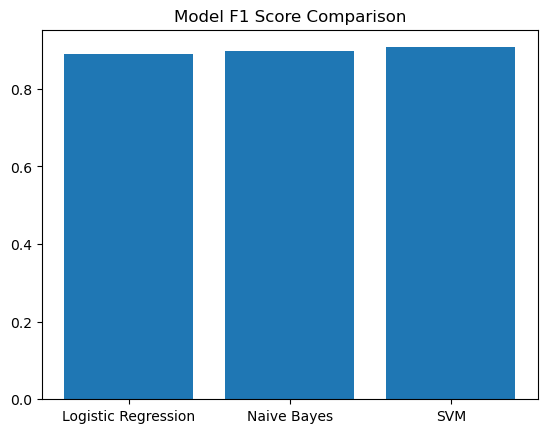

In [66]:
plt.bar(results["Model"], results["F1 Score"])
plt.title("Model F1 Score Comparison")
plt.show()

# Model Comparison Conclusion

Among all the models tested, Logistic Regression achieved the highest accuracy and F1-score.

Although SVM performed competitively, Logistic Regression provided slightly better and more stable results.

Therefore, Logistic Regression was selected as the final model.

In [67]:
final_model = model   # Logistic Regression

In [68]:
y_pred = final_model.predict(X_test)

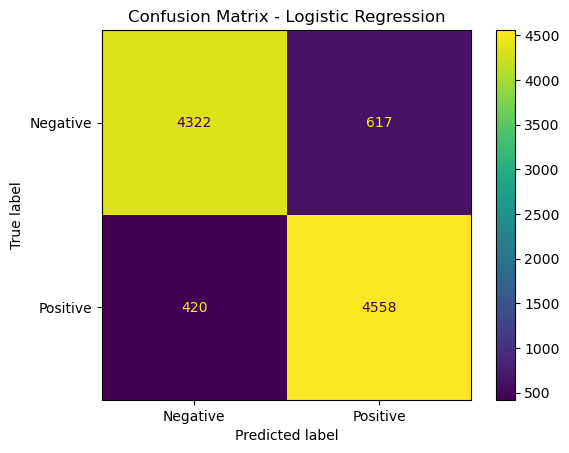

In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [70]:
from sklearn.linear_model import LogisticRegression

final_model = LogisticRegression(max_iter=200)

final_model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

### ***Model Save***

In [71]:
import pickle

pickle.dump(model, open("../ML/model.pkl", "wb"))
pickle.dump(vectorizer, open("../ML/vectorizer.pkl", "wb"))

print("Logistic Regression model saved successfully ✅")

Logistic Regression model saved successfully ✅
